# Get the required library

In [1]:
import torch
import gc

# # Agar ye variables exist karte hain (pehle wale Qwen models)
# del merged_model
# del original_model
# del lora_model   # agar purana Qwen LoRA model bhi memory mein hai

gc.collect()
torch.cuda.empty_cache()

# print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from peft import LoraConfig, TaskType, get_peft_model, peft_model

from datasets import load_dataset, Dataset, DatasetDict

from trl import DPOConfig, DPOTrainer


from huggingface_hub import hf_hub_download
import json, pymupdf

import pytesseract
from PIL import Image
import io, pandas as pd, numpy as np



In [5]:
import torch
device = ("cuda" if torch.cuda.is_available() else "cpu")
device

'cuda'

# Load the Data


In [6]:
# Reading to valid rows from ocr
valid_rows=[]
skipped_rows=[]
with open ("pharma_ocr_text.jsonl", "r", encoding='utf-8') as f:
    for l in f:
        if len(l)>50:
            try:
                row=json.loads(l)
                valid_rows.append(row)
            except Exception as e:
                skipped_rows.append(row)
                print("Bad rows are present")
                print(f"{e}\n\n{row}")
print(valid_rows[1])
print()
print(skipped_rows)
           



        

{'page': 2, 'text': 'ALL RIGHTS RESERVED\n\nFirst Published 1975\n\nPUBLISHED BY J. SINHA, SCIENTIFIC BOOK AGENCY, 22 RAJA WOODMUNT\nUl . , toe . .\n\nSTREET, CALCUTTA 1 AND PRINTED BY DEBDAS NATH, SADHANA PRESS\n\nPRIVATE LIMITED, 76 séPikt BEHARI GANGULI STREET, CALCUTTA 12'}

[]


In [7]:
import json
from datasets import Dataset

# 1. OCR text
ocr_texts = [row['text'] for row in valid_rows]

# 2. Katzung textbook — SAHI FILE PATH
pharma_file_path = "/root/.ssh/medqa_textbooks/textbooks/en/Pharmacology_Katzung.jsonl"
katzung_texts = []
with open(pharma_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if len(line) >= 30:
            row = json.loads(line)
            katzung_texts.append(row['text'])

print(f"Katzung records loaded: {len(katzung_texts)}")

# 3. Combine
combined_texts = ocr_texts + katzung_texts
print(f"Total combined records: {len(combined_texts)}")

# 4. Dataset
inp0_combined = Dataset.from_dict({"text": combined_texts})
inp0 = inp0_combined
print(inp0)

Katzung records loaded: 4505
Total combined records: 5440
Dataset({
    features: ['text'],
    num_rows: 5440
})


# Simple Analysis of the data

In [8]:
# import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
df=pd.DataFrame(inp0)
df.drop_duplicates(inplace=True)
df.isna().sum()



text    0
dtype: int64

In [9]:
df['text_length']=df['text'].str.split().apply(len)
df['aprox_token']=df['text_length']*1.5
df.tail()

,text,text_length,aprox_token
5435,Rubella Immune globulin (IM) 0.55 mL/kg IM. No...,220,330.0
5436,Treatment of severe reactions to vaccinia vacc...,150,225.0
5437,It is the physician's responsibility to inform...,194,291.0
5438,"Every adult, whether traveling or not, should ...",200,300.0
5439,General recommendations on immunization. Recom...,172,258.0


In [10]:
import matplotlib.pyplot as plt, seaborn as sns

Text(0.5, 1.0, "5 Number's Summary of The Text Length")

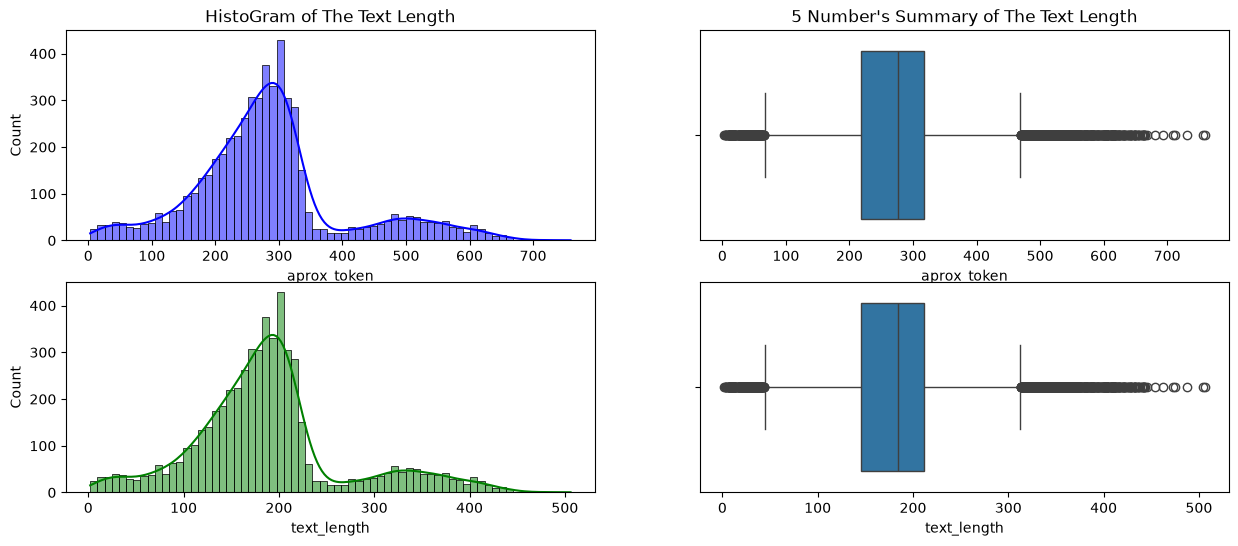

In [11]:
# Normal Analysis of the data


fig, ax = plt.subplots(2,2, figsize=(15,6))
sns.histplot(data=df, x='aprox_token',kde=True,color='b' ,ax=ax[0,0])
ax[0,0].set_title("HistoGram of The Aprox Token")


sns.boxplot(data=df, x='aprox_token' ,ax=ax[0,1] )
ax[0,1].set_title("5 Number's Summary of The Aprox Token")



sns.histplot(data=df, x='text_length',kde=True,color='g' ,ax=ax[1,0])
ax[0,0].set_title("HistoGram of The Text Length")


sns.boxplot(data=df, x='text_length' ,ax=ax[1,1] )
ax[0,1].set_title("5 Number's Summary of The Text Length")

In [12]:
# Defining Max Token

max_token=max(int(df['aprox_token'].quantile(.95)//1) , 600)
max_token


600

In [ ]:
MODEL_ID = "Qwen/Qwen1.5-1.8B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)   # dtype hata diya

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token   # 'eos_tokens' → 'eos_token'

# Non Instructional Base Model

In [14]:
# Base Model in cpu
# base_model_non_instruct = AutoModelForCausalLM.from_pretrained(MODEL_ID)

In [18]:
import bitsandbytes as bnb
import transformers

print("bitsandbytes:", bnb.__version__)
print("transformers:", transformers.__version__)

bitsandbytes: 0.50.2
transformers: 5.17.0


In [ ]:
# Quantize Run in Runpod GPU

from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model_non_instruct = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

In [ ]:
# Mass tokenizer 

def tokenizer_fn(example):
    token = tokenizer(example['text'],   max_length=max_token, padding="max_length", truncation=True)
    token['labels']=token['input_ids'].copy()

    return token


In [ ]:
# # Down Grade the inp0 
# inp0=inp0.select(range(10,20))
# inp0

In [ ]:
# Toknized data

encoded_data = inp0.map(tokenizer_fn,batched=True ,batch_size=64, remove_columns=['text'])
encoded_data

Map:   0%|          | 0/5440 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 5440
})

In [ ]:
# Check How many input ids are there 
len(encoded_data['input_ids'])

5440

In [ ]:

# Lora Config
lora_config= LoraConfig(
    task_type=TaskType.CAUSAL_LM
    ,r=8
    ,lora_alpha=16
    ,target_modules=['q_proj', "v_proj"]
    ,lora_bias=None
    ,lora_dropout=0.05
    
)

In [ ]:
# Get the model
lora_model = get_peft_model(base_model_non_instruct, lora_config).to(device)

/root/.ssh/ktl_env/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/root/.ssh/ktl_env/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
model_dir=f'./ktl_{MODEL_ID}_non_instruct'
model_dir

'./ktl_Qwen/Qwen2.5-7B_non_instruct'

In [ ]:
import transformers
print(transformers.__version__)

5.17.0


In [ ]:
print(device)

training_arg = TrainingArguments(
    output_dir=model_dir,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_total_limit=1,
    weight_decay=0.05,
    save_strategy='epoch',
    warmup_steps=50,              
    lr_scheduler_type="cosine",
    report_to="none",
)

cuda


In [ ]:
# Trainer

trainer_non_instruct = Trainer(
    model = lora_model, args=training_arg, train_dataset=encoded_data
)

In [ ]:
# Train the model 
trainer_non_instruct.train()

In [ ]:
# Check the perplexcity
import math


def calculate_perplexity(model, tokenizer, text, device):
    encodings = tokenizer(text, return_tensors="pt").to(device)
    input_ids = encodings.input_ids
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss
    return math.exp(loss.item())

# Multiple test texts — real pharma content, alag topics se
test_texts = [
    "The mechanism of action of ACE inhibitors involves inhibition of angiotensin-converting enzyme, reducing the conversion of angiotensin I to angiotensin II.",
    "Beta-blockers competitively inhibit catecholamine binding to beta-adrenergic receptors, resulting in decreased heart rate and myocardial contractility.",
    "Pharmacokinetics encompasses absorption, distribution, metabolism, and excretion of drugs within the body.",
    "Epilepsy is characterized by recurrent, unprovoked seizures resulting from abnormal electrical activity in the brain.",
    "The abbreviation b.i.d. on a prescription means the medication should be taken twice daily.",
]

# Load original (non-fine-tuned) model for comparison
print("Loading original base model for comparison...")
original_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen1.5-1.8B").to(merged_model.device)

print("\n" + "="*90)
print(f"{'Test Text (truncated)':<50} {'Original PPL':>15} {'Fine-tuned PPL':>15}")
print("="*90)

original_ppls = []
finetuned_ppls = []

for text in test_texts:
    ppl_original = calculate_perplexity(original_model, tokenizer, text, merged_model.device)
    ppl_finetuned = calculate_perplexity(merged_model, tokenizer, text, merged_model.device)
    
    original_ppls.append(ppl_original)
    finetuned_ppls.append(ppl_finetuned)
    
    print(f"{text[:47]+'...':<50} {ppl_original:>15.2f} {ppl_finetuned:>15.2f}")

print("="*90)
print(f"{'AVERAGE':<50} {sum(original_ppls)/len(original_ppls):>15.2f} {sum(finetuned_ppls)/len(finetuned_ppls):>15.2f}")
print("="*90)

Loading original base model for comparison...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


Test Text (truncated)                                 Original PPL  Fine-tuned PPL
The mechanism of action of ACE inhibitors invol...            4.22            4.32
Beta-blockers competitively inhibit catecholami...            6.73            8.27
Pharmacokinetics encompasses absorption, distri...            4.94            8.96
Epilepsy is characterized by recurrent, unprovo...            4.10            6.07
The abbreviation b.i.d. on a prescription means...           27.65           29.28
AVERAGE                                                       9.53           11.38


In [ ]:
# Save Model 
trainer_non_instruct.save_model(model_dir + "/final")
tokenizer.save_pretrained(model_dir + "/final")

print(f"Model saved to {model_dir}/final")

Model saved to ./ktl_Qwen/Qwen1.5-1.8B_non_instruct/final


In [ ]:
# Merge and unload the model
merged_model = lora_model.merge_and_unload()
merged_model.save_pretrained(model_dir + "/merged_for_stage2")
tokenizer.save_pretrained(model_dir + "/merged_for_stage2")

/root/.ssh/ktl_env/lib/python3.12/site-packages/peft/tuners/lora/bnb.py:377: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./ktl_Qwen/Qwen1.5-1.8B_non_instruct/merged_for_stage2/tokenizer_config.json',
 './ktl_Qwen/Qwen1.5-1.8B_non_instruct/merged_for_stage2/chat_template.jinja',
 './ktl_Qwen/Qwen1.5-1.8B_non_instruct/merged_for_stage2/tokenizer.json')

# Check the Model output

In [ ]:
test_prompts = [
    "Pharmacokinetics is the term that describes",
    "The mechanism of action of beta blockers",
    "Epilepsy is a cerebral disorder characterized by",
    "b.i.d. means",
]

for prompt in test_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(merged_model.device)
    with torch.no_grad():
        output = merged_model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            do_sample=True,
        )
    print(f"PROMPT: {prompt}")
    print(f"OUTPUT: {tokenizer.decode(output[0], skip_special_tokens=True)}")
    print("-" * 80)

PROMPT: Pharmacokinetics is the term that describes
OUTPUT: Pharmacokinetics is the term that describes how drugs move through and interact with biological systems. The principles of pharmacokinetics are based on basic physiology, as well as chemistry.
The principle behind Pharmacokinetics is this: Drugs can pass into blood cells (lymphocytes) via a process called lymphatic flow; once inside these cells they can then pass through to other tissues or organs throughout our bodies. As a result, there’s an inherent variability in drug concentrations depending upon location within your body – from the liver where most drugs are broken
--------------------------------------------------------------------------------
PROMPT: The mechanism of action of beta blockers
OUTPUT: The mechanism of action of beta blockers is to block the effects of adrenaline and acetylcholine on peripheral vasculature. The effect of a drug depends upon which receptors are activated (or blocked) in which organ system, 

In [ ]:
# Push the model to hugging face

from huggingface_hub import login
login(token="hf_your_token")   # same token jo pehle use kiya tha

from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained("Kuntal090/qwen1.5-1.8b-pharma-stage1")
tokenizer = AutoTokenizer.from_pretrained("Kuntal090/qwen1.5-1.8b-pharma-stage1")

In [ ]:
# Get the Model From Hugging Face

model = AutoModelForCausalLM.from_pretrained("Kuntal090/qwen1.5-1.8b-pharma-stage1")
tokenizer = AutoTokenizer.from_pretrained("Kuntal090/qwen1.5-1.8b-pharma-stage1")

print("Model aur tokenizer successfully download ho gaye")

config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.87GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/327 [00:00<?, ?B/s]

Model aur tokenizer successfully download ho gaye


# Check the ouput 

In [12]:
import torch

model.eval()

test_prompts = [
    # Mechanism of action
    "The mechanism of action of ACE inhibitors is",
    "Beta-adrenergic receptors are classified into",
    
    # Definitions/concepts
    "Bioavailability is defined as",
    "The therapeutic index of a drug refers to",
    
    # Disease/condition descriptions
    "Hypertension is managed through",
    "Type 2 diabetes mellitus is characterized by",
    
    # Prescription/practical terminology
    "The abbreviation q.i.d. means",
    "A loading dose is used when",
    
    # Drug classes
    "NSAIDs work by inhibiting",
    "Antibiotics such as penicillin function by",
]

for prompt in test_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            do_sample=True,
        )
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"PROMPT: {prompt}")
    print(f"OUTPUT: {generated}")
    print("-" * 90)

PROMPT: The mechanism of action of ACE inhibitors is
OUTPUT: The mechanism of action of ACE inhibitors is through inhibition of which enzyme?
A: Angiotensin 2 receptor
B: Angiopoietins (Ang)
C: Angiotensin converting enzyme
D: Cystic fibrosis

Assistant:
C
------------------------------------------------------------------------------------------
PROMPT: Beta-adrenergic receptors are classified into
OUTPUT: Beta-adrenergic receptors are classified into four types according to their subtypes (α,β,γ and δ). α- receptors are the most abundant type of adrenoreceptors in blood vessels. They play a central role for maintaining homeostasis by regulating hemodynamic factors including vascular tone, pressure and cardiac output.
In human body, β-receptor is mainly found at heart muscle cells where it plays an important role as a Ca
------------------------------------------------------------------------------------------
PROMPT: Bioavailability is defined as
OUTPUT: Bioavailability is defined as 

# Check Model Output and Base model output 

In [ ]:
# Fine tuned non-instruct model output

prompt="What is BID meaning in prescription?"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.1,
        top_p=0.99,
        # repetition_penalty=1.2,
        do_sample=True,
    )
generated = tokenizer.decode(output[0], skip_special_tokens=True)
print(f"PROMPT: {prompt}")
print(f"OUTPUT: {generated}")
print("-" * 90)

PROMPT: What is BID meaning in prescription?
OUTPUT: What is BID meaning in prescription? BID is a term used in the pharmaceutical industry to indicate the time of day when a medication is to be taken. It stands for "bid" which means "twice a day". So, if you take your medication at 10:00 AM, you would take it at 10:00 AM and 2:00 PM.
------------------------------------------------------------------------------------------


In [30]:
base_model=AutoModelForCausalLM.from_pretrained(MODEL_ID)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
# Base Model non-instruct : output

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    output = base_model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        do_sample=True,
    )
generated = tokenizer.decode(output[0], skip_special_tokens=True)
print(f"PROMPT: {prompt}")
print(f"OUTPUT: {generated}")
print("-" * 90)

PROMPT: What is BID meaning in prescription?
OUTPUT: What is BID meaning in prescription? - Medical Dictionary
BID Meaning.
Learn More About Prescription
More about BID, definition of BID by the Online Drugs & Pharmacy dictionary
------------------------------------------------------------------------------------------
